# Densitetsbaserad klustring av elnätets övervakningsplatser med PROC MODECLUS


## Sammanfattning

Ett eldistributionsbolag använder PROC MODECLUS för att hitta ickeparametriska,
densitetsbaserade kluster bland sina övervakningsplatser i nätet (transformatorstationer
och matarledningssensorer) enbart utifrån deras kartkoordinater. MODECLUS skattar en
densitetsyta över platserna och behandlar kluster som högdensitetsregioner åtskilda av
lågdensitetsluckor. Att köra det på 90 simulerade platser med en enhetlig kärnradie på
3 km återfinner de tre täta serviceklungor vi byggde in i datat som de tre största
klustren (24, 24 och 21 platser), medan de spridda landsbygdsplatserna hamnar i glesa
regioner och delar upp sig i egna mikrokluster med ett eller två platser. Den mängden
isolerade platser är den operativa leveransen: en kandidatlista över avlägsna
tillgångar för kapitalplaneringsteamet.


## Datakällor

| Dataset | Rader | Beskrivning |
|---------|------|-------------|
| `grid_sites` | 90 | Syntetiska eldistributions-övervakningsplatser genererade direkt med `call streaminit(70531)` och `rand()`. Tre täta serviceklungor (UrbanCore, Suburban, Industrial) dragna från bivariata normalfördelningar kring skilda kartcentroider, plus 22 spridda Rural-platser dragna likformigt över territoriet. |

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `site_id` | Num | Unik identifierare för övervakningsplats (1-90). |
| `region` | Char | Planeringsetikett som anger hur varje plats genererades (UrbanCore, Suburban, Industrial, Rural); hålls utanför klustringen. |
| `x_km`, `y_km` | Num | Platsens position i kilometer på bolagets planeringsnät; klustringsvariablerna. |
| `peak_load_mw` | Num | Observerad årlig toppbelastning (MW) vid platsen; följer med för nedströms tolkning. |


# Densitetsbaserad klustring av elnätets övervakningsplatser

Ett regionalt eldistributionsbolag driver ett nätverk av **övervakningsplatser**
-- transformatorstationer och matarledningssensorer -- spridda över sitt
serviceområde. Planerarna vill gruppera dessa platser i naturliga **serviceklungor**
baserat enbart på geografi, utan att i förväg ange hur många grupper som finns, och
identifiera **isolerade landsbygdstillgångar** som inte tillhör någon tät klunga.

`PROC MODECLUS` passar utmärkt för detta: den utför *ickeparametrisk,
densitetsbaserad* klustring. Den skattar en densitetsfunktion över platserna och
behandlar sedan kluster som regioner med hög platsdensitet åtskilda av
lågdensitetsluckor. Glesa avvikare hamnar i sina egna små kluster istället för att
absorberas i en klunga -- precis det beteende vi vill ha för att flagga avlägsna
platser.

Denna notebook:
1. Genererar ett realistiskt syntetiskt nätverk av 90 platser.
2. Skattar platsdensitet med en **enhetlig kärna** och skannar utjämningsradien
   `R=` för att bekräfta att de återfunna klungorna är stabila.
3. Fixerar en arbetsradie, skriver ett `OUT=`-dataset med varje plats densitet och
   klusteretikett, och kartlägger resultatet.


## Steg 1 -- Generera ett syntetiskt nätverk av övervakningsplatser

Vi simulerar 90 platser. Tre täta **serviceklungor** dras från bivariata
normalfördelningar kring skilda kartcentroider (UrbanCore nära (12, 30), Suburban
nära (30, 15), Industrial nära (20, 42)), vilket ger kompakta högdensitetsblobbar
på 24, 24 och 20 platser. En fjärde uppsättning på 22 **Rural**-platser dras
likformigt över territoriet, vilket ger de glesa, spridda platser ett bolag skulle
behandla som isolerade.

Etiketten `region` anger hur varje plats genererades; vi håller den medvetet
**utanför** klustringen så att MODECLUS återupptäcker strukturen enbart från
koordinaterna. `peak_load_mw` följer med för senare tolkning.


In [1]:
data grid_sites;
   CALL streaminit(70531);
   LÄNGD region $ 16;

   /* Tät urban serviceklunga */
   GÖR site_id = 1 TILL 24;
      region = 'Stadskärna';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      UTDATA;
   SLUT;

   /* Förortsklunga */
   GÖR site_id = 25 TILL 48;
      region = 'Förort';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      UTDATA;
   SLUT;

   /* Industriklunga (högre toppbelastning) */
   GÖR site_id = 49 TILL 68;
      region = 'Industri';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      UTDATA;
   SLUT;

   /* Spridda landsbygdsplatser (glesa, låg belastning) */
   GÖR site_id = 69 TILL 90;
      region = 'Landsbygd';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      UTDATA;
   SLUT;
KÖR;

TITEL 'Syntetiska övervakningsplatser i elnätet';
PROCEDUR MEANS data=grid_sites n mean std MIN MAX maxdec=2;
   KLASS region;
   VARIABEL x_km y_km peak_load_mw;
   ETIKETT region="Region" x_km="Öst-koordinat (km)" y_km="Nord-koordinat (km)" peak_load_mw="Toppbelastning (MW)";
KÖR;


                                        Syntetiska övervakningsplatser i elnätet                                        

                                                  The MEANS Procedure

                                      Analysis Variable : x_km Öst-koordinat (km)

        Region               N Obs           Mean        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------
        Förort                  24          29.96           1.73          26.51          33.60
        Industri                20          20.36           0.96          18.52          21.53
        Landsbygd               22          29.79          10.62          11.06          47.45
        Stadskärna              24          12.07           1.34           8.65          14.42
        --------------------------------------------------------------------------------------

                                      Analysis Variable : 


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Syntetiska övervakningsplatser i elnätet.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Medelvärdena bekräftar tre täta klungor och en diffus grupp. De tre täta
regionerna har små standardavvikelser i koordinaterna (ungefär 1-1.7 km på varje
axel) kring väl separerade centroider, medan Landsbygd-gruppen sprider sig över
hela nätet (standardavvikelser över 10 km på båda axlarna). Toppbelastningen
separerar också klungorna -- Industri-platser har i genomsnitt ungefär 6 MW,
Stadskärna ungefär 4.6 MW, Förort ungefär 2.7 MW, och Landsbygd-platser ungefär
1.5 MW -- vilket är användbar kontext när de geografiska klustren väl är på plats.


## Steg 2 -- Enhetlig kärntäthetsklustring och en radieskanning

Enhetlig kärntäthetsskattning använder en **radie `R=`**: varje plats inom `R`
kilometer bidrar till en plats lokala densitet. Litet `R` ger en skrovlig densitet
som fragmenterar territoriet; stort `R` överutjämnar och slår ihop klungor. En
SAS-expert litar aldrig på ett enda värde -- de skannar ett intervall av radier
och letar efter ett klusterantal som är **stabilt**, där de täta klungorna
består medan bara antalet spridda singletoner driver.

Här väljer `M=1` klustringsmetod 1 (standardmetoden, ickeparametrisk), och vi
begär radierna `R=2.5 to 4 by 0.5` i ett enda anrop. MODECLUS kör analysen en
gång per radie och rapporterar antalet kluster för varje. `SHORT` undertrycker
den utförliga per-klusterstatistiken.


In [2]:
TITEL 'Enhetlig kärntäthetsklustring av nätplatser';
title2 'Radieskanning R = 2.5 till 4.0 km';

PROCEDUR modeclus data=grid_sites m=1 r=2.5 TILL 4 EFTER 0.5 short;
   VARIABEL x_km y_km;
   id site_id;
KÖR;


                                      Enhetlig kärntäthetsklustring av nätplatser                                       
                                           Radieskanning R = 2.5 till 4.0 km                                            


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Enhetlig kärntäthetsklustring av nätplatser.
NOTE: Option TITLE2 changed to Radieskanning R = 2.5 till 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Klusterantalet rör sig bara försiktigt över skanningen -- 23 kluster vid
`R=2.5`, 22 vid `R=3.0`, 19 vid `R=3.5`, och 18 vid `R=4.0`. De höga råtalen
kommer från de spridda landsbygdsplatserna: varje isolerad plats sitter i sitt
eget glesa grannskap och bildar ett enplatskluster, så de flesta av de 18-23
"klustren" är singletoner. Det som förblir konstant under ytan är strukturen
som spelar roll -- de tre täta klungorna förblir tre stora, väl separerade
kluster vid varje radie. När `R` breddas slår några av de spridda singletonerna
ihop sig med en granne eller en närliggande klunga, vilket är varför det totala
antalet driver långsamt nedåt istället för att svänga vilt. Den stabiliteten är
signalen att lösningen med tre klungor är verklig och inte en artefakt av en
enda bandbredd.


## Steg 3 -- Slutlig klustrad lösning för kartläggning

Efter att ha sett att de tre klungorna är stabila över skanningen fixerar vi en
enda arbetsradie (`R=3` km) och begär **ALL**-alternativet för den fullständiga
per-klustervisningen, plus **OUT=** för att skriva de ursprungliga koordinaterna
tillsammans med `DENSITY`-skattningen och `CLUSTER`-tilldelningen så att vi kan
kartlägga resultatet. Kluster numreras i fallande modaldensitet, så de tätaste
klungorna är kluster 1, 2 och 3 och de glesa platserna får de högre numren.


In [3]:
TITEL 'Slutlig densitetsbaserad klusterlösning';
title2 'Enhetlig kärna, R = 3 km';

PROCEDUR modeclus data=grid_sites m=1 r=3 out=join_out ALL;
   VARIABEL x_km y_km;
   id site_id;
KÖR;


                                        Slutlig densitetsbaserad klusterlösning                                         
                                                Enhetlig kärna, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to Slutlig densitetsbaserad klusterlösning.
NOTE: Option TITLE2 changed to Enhetlig kärna, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


Klustersammanfattningen gör strukturen tydlig. `R=3`-lösningen ger
**22 kluster**, men de är skarpt uppdelade efter densitet:

- **Kluster 1** -- 24 platser, modaldensitet ungefär 0.0090 (Stadskärna-klungan).
- **Kluster 2** -- 24 platser, modaldensitet ungefär 0.0079 (Förort-klungan).
- **Kluster 3** -- 21 platser, modaldensitet ungefär 0.0079 (Industri-klungan;
  den plockar upp en landsbygdsplats som råkade hamna på dess kant).
- **Kluster 4-22** -- en grupp på tre platser och arton enplatskluster, alla vid
  modaldensitet ungefär 0.0004, ungefär tjugo gånger glesare än klungorna.

De tre täta klungorna står för 69 av de 90 platserna; de återstående 21 platserna
är de spridda landsbygdstillgångarna, var och en sittande ensam eller nästan
ensam i ett lågdensitetsgrannskap. Densitet, inte ett förutbestämt klusterantal,
drar linjen mellan en serviceklunga och en isolerad plats.


## Steg 4 -- Kartlägg klustren

Vi märker varje plats efter om den hamnade i en av de tre täta klungorna
(`cluster <= 3`) eller i ett glest mikrokluster, och plottar sedan varje plats
vid dess kartkoordinater färgad efter den statusen. Det här är planerarens vy:
täta klungor att hantera som serviceområden, och isolerade platser att flagga
för separat behandling.


                                     Återfunna serviceklungor och isolerade platser                                     
                                        Enhetlig kärntäthetsklustring, R = 3 km                                         




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Återfunna serviceklungor och isolerade platser.
NOTE: Option TITLE2 changed to Enhetlig kärntäthetsklustring, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


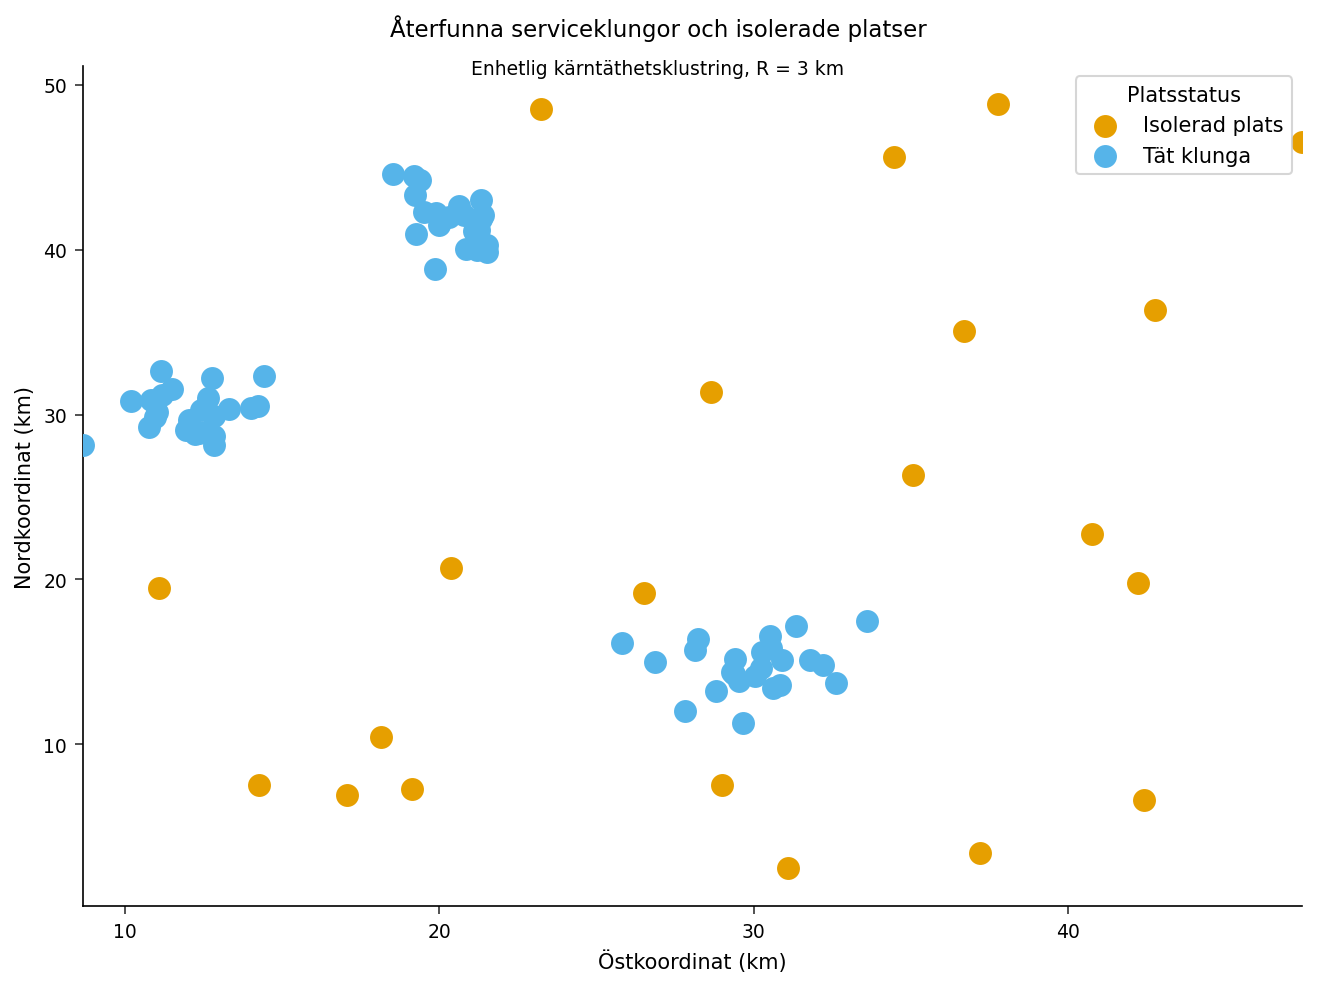

In [4]:
data mapped;
   STÄLL_IN join_out;
   LÄNGD status $ 16;
   OM cluster <= 3 SÅ status = 'Tät klunga';
   ANNARS status = 'Isolerad plats';
KÖR;

TITEL 'Återfunna serviceklungor och isolerade platser';
title2 'Enhetlig kärntäthetsklustring, R = 3 km';
PROCEDUR SGPLOT data=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=cluster
                           MARKERATTRS=(size=10);
   XAXIS ETIKETT='Östkoordinat (km)';
   YAXIS ETIKETT='Nordkoordinat (km)';
   keylegend / TITEL='Platsstatus';
KÖR;

TITEL;


## Tolkning av resultaten

**Vad MODECLUS hittade.** Drivet enbart av `(x_km, y_km)` återfinner proceduren
de tre täta serviceklungorna vi byggde in i datat -- UrbanCore-, Suburban- och
Industrial-blobbarna -- som de tre största, tätaste klustren (24, 24 och 21
platser). De spridda landsbygdsplatserna, dragna likformigt över territoriet,
hamnar i glesa regioner och delar upp sig i egna kluster med ett eller två
platser istället för att absorberas i en klunga. På kartan är de punkterna
separerade från de tre täta blobbarna. Den isolerade mängden är den operativa
leveransen: en kandidatlista över avlägsna tillgångar för
kapitalplaneringsteamet.

**Varför utjämningsskanningen spelar roll.** Ingen enskild `R` är auktoritativ
för ickeparametrisk densitetsklustring. Att skanna `R=2.5 to 4 by 0.5` låter oss
bekräfta att klungorna är *stabila* över utjämningsnivåer snarare än en artefakt
av en enda bandbredd. Över skanningen rör sig klusterantalet bara från 23 ner
till 18, och förändringen ligger helt i antalet spridda singletoner -- de tre
täta klungorna består genomgående. Där strukturen höll sig stabil så här har vi
en försvarbar lösning; om antalet hade svängt vilt skulle strukturen vara
skör och inte styra investeringsbeslut.

**Densitet graderar resultatet.** Eftersom kluster numreras i fallande
modaldensitet är uppdelningen mellan klungor och isolerade platser kvantitativ,
inte godtycklig: de tre klungorna ligger nära modaldensitet 0.008-0.009 medan
varje isolerad plats ligger nära 0.0004, ungefär tjugo gånger glesare. En
planerare kan sätta ett densitetsgolv och läsa av de isolerade tillgångarna
direkt från kolumnerna `CLUSTER` och `DENSITY` i `join_out`.

**Praktisk användning.** Datasetet `join_out` ger varje plats en densitet och en
klusteretikett som kan användas som utgångspunkt för nedströms arbete --
dimensionering av arbetslag och reservdelar per serviceklunga, ruttplanering
för inspektionskretsar, eller prioritering av nätförstärkning i den täta
industriklustret (högst `peak_load_mw`, ungefär 6 MW) samtidigt som de
isolerade landsbygdsplatserna schemaläggs för separat underhåll med lägre
frekvens.

*Anmärkning om syntetiska data:* koordinater och belastningar simuleras med en
fast seed (`call streaminit(70531)`) så notebooken är helt reproducerbar
offline; på verkliga bolagsdata skulle du ersätta med inmätta platskoordinater
och uppmätta toppbelastningar. De exakta klusterantalen beror på det slumpmässiga
draget och på den valda radien.
